# HMM Bias Comparison

In [132]:
# Whether to recompute results
RERUN = false

false

In [1]:
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl")

subject_cov (generic function with 1 method)

In [2]:
fns_hmm = [
    ("hmm_leaf", run_hmm_leaf),
    ("hmm_leaf_γ2", run_hmm_leaf_γ2),
    ("hmm_leaf_retainbelief", run_hmm_leaf_retainbelief),
    ("hmm_leaf_stay", run_hmm_leaf_stay),
    ("hmm_leaf_turn", run_hmm_leaf_turn),
    ("hmm_leaf_spatial", run_hmm_leaf_spatial),
    ("hmm_leaf_leafturn", run_hmm_leaf_leafturn),
    ("hmm_leaf_leafspatial", run_hmm_leaf_leafspatial),
]
fns_hmm_stay = [
    ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2),
    ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief),
    ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial),
    ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn),
    ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial),
    ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn),
    ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial),    
    ]
fns_hmm_γ2 = [
    ("hmm_leaf_turn_γ2", run_hmm_leaf_turn_γ2),
    ("hmm_leaf_spatial_γ2", run_hmm_leaf_spatial_γ2),
    ("hmm_leaf_turn_leafturn_γ2", run_hmm_leaf_turn_leafturn_γ2),
    ("hmm_leaf_turn_leafspatial_γ2", run_hmm_leaf_turn_leafspatial_γ2),
    ("hmm_leaf_spatial_leafturn_γ2", run_hmm_leaf_spatial_leafturn_γ2),
    ("hmm_leaf_spatial_leafspatial_γ2", run_hmm_leaf_spatial_leafspatial_γ2),
    ]
fns_hmm_stay_γ2 = [
    ("hmm_leaf_stay_turn_γ2", run_hmm_leaf_stay_turn_γ2),
    ("hmm_leaf_stay_spatial_γ2", run_hmm_leaf_stay_spatial_γ2),
    ("hmm_leaf_stay_turn_leafturn_γ2", run_hmm_leaf_stay_turn_leafturn_γ2),
    ("hmm_leaf_stay_turn_leafspatial_γ2", run_hmm_leaf_stay_turn_leafspatial_γ2),
    ("hmm_leaf_stay_spatial_leafturn_γ2", run_hmm_leaf_stay_spatial_leafturn_γ2),
    ("hmm_leaf_stay_spatial_leafspatial_γ2", run_hmm_leaf_stay_spatial_leafspatial_γ2),
    ]
fns = vcat(fns_hmm, fns_hmm_stay, fns_hmm_γ2, fns_hmm_stay_γ2);
# fns = fns_leaf

In [3]:
if RERUN
    for animal in animals
        for (fname, fn) in fns_leafbias
            results = fn(load_animal(animal, filepath))
            save("$(filepath)/results/hmm_biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)", results)
        end
    end
end

LoadError: UndefVarError: RERUN not defined

In [4]:
function load_hmm_results(animals, fns; rewscaled=false)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    if rewscaled
        add_rewscaled = "_rewscaled"
    else
        add_rewscaled = ""
    end
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/hmm_biases/$(fname)$(add_rewscaled)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)$(add_rewscaled)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_hmm_results (generic function with 1 method)

## HMM model

We consider a *state* to be a particular assignment of reward probabilities to each of the 6 reward ports.

For example, one hypothetical state might be

$\text{state} = [p_1=0.3, p_2=0.5, p_3=0.4, p_4=0.4, p_5=0.8, p_6=0.9]$

In the HMM, we're modeling our *belief* about which of a number of discrete states we're currently in. These states correspond to the *contingencies* that are actually used to provide rewards for the rats. Our set of contingencies, $\phi$, is a subset 72 of these possible contingencies. 

We assume we are in 1 of these 72 contingencies on any given trial, but with some uncertainty about which of these states we're in. Our belief state, $\alpha$, is a probabilitiy distributon over these 72 contingencies. 

We're assuming any contingency can transition to any other contingency, with some fixed probability, or $\text{volatility}$. This volatility, while fixed, has to be inferred (and is a parameter we fit)

Key terms:
- $\phi$: Set of possible contingencies (72 x 6)
- $\alpha$: Agent's belief state (1 x 72)
- $\text{volatility}$: Probability of contingency change each trial

So on any given trial, we can combine our belief state $\alpha$ with the set of contingencies $\phi$ to find our expected probability of reward at each of the six ports:

\begin{equation}
Q = \alpha * \phi
\end{equation}

Finally, at the end of each trial, we observe an outcome. We want to update $\alpha$ based on the probability of that outcome for each contingency. 

If the outcome was positive, the probability of that simply is the value of $\phi$ for that contingency and leaf, and so $\alpha_i \leftarrow \alpha_i \phi_{ij}$ for contingency $i$ and leaf $j$

If the outcome was negative, this becomes $\alpha_i \leftarrow \alpha_i (1 - \phi_{ij})$

## Choice Simulation

We separately model **stem** and **leaf** choices.

**Stem choice** is a based on a single `Qstem` value for each of the 3 stems
- For the current stem, this is the reward of the upcoming leaf
- For the other two stems, this is the average reward of the two leaves

We model the choice as `softmax` of the three stems, which at simplest would be
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta \text{Qstem}_1}}{e^{\beta \text{Qstem}_1 + \beta \text{Qstem}_2 + \beta \text{Qstem}_3}}
\end{equation}

However, to allow for some additional flexibility, the current stem has a separate $\beta$ from the other two:
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta_\text{stay} \text{Qstem}_1}}{e^{\beta_{stay} \text{Qstem}_1 + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

(Here we're assuming stem 1 is the current stem)

## Overview of model biases

### Stay Bias

One straightforward change is to add an offset for how much better the reward needs to be at another stem for us to change. This is incorporated as a constant addition to the current stem, after $\beta_{stay}$:

\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1 + \text{stay}}}{e^{\beta_{stay} \text{Qstem}_1 + \text{stay} + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

Note that this is different from the separate $\beta_{go}$ and $\beta_{stay}$ terms: While those affect the sharpness of the choice (how much of an effect a change of reward has), the $\text{stay}$ term instead changes the point at which *stay* vs. *go* is equally weighted.

## γ2

As mentioned earlier, $\text{Qstem}$ for the current stem is taken to be the upcoming leaf, ignoring the leaf we're leaving.

While empirically, the rats are primarily driven by the upcoming leaf, they probably don't entirely ignore the other leaf.

We can add a weight, $\gamma 2$, giving us

\begin{equation}
\text{Qstem} = \beta_\text{stay} * (Q_2 + \gamma 2 * Q_1) 
\end{equation}

Defaults to 0

## Retain Belief (across sessions)

At the start of a day, we assume rats place equal weight on all contingencies: $\alpha_n = 1/72$ for all $n$

However, what happens between sessions on the same day? By default, we're resetting the belief to the flat prior, but we can also incorporate some of the prior belief:

\begin{equation}
\alpha = (\text{retain_belief} * \alpha) + ((1 - \text{retain_belief}) * \alpha\text{Prior})
\end{equation}

Defaults to 0

# γ2, stay, and retainbelief biases

First, let's take a look at a few independent choices and their effect on model fit:
- `γ2`: Weight applied to the leaf we're *leaving* on the current stem
- `stay`: Constant bias applied to current stem
- `retainbelief`: Do we allow a fraction of our belief state (contingency belief) to persist between sessions?

On the left, we see IAIC values for baseline and all three bias terms

On the right, we see the improvement (decrease) in IAIC for the latter 3 versus baseline

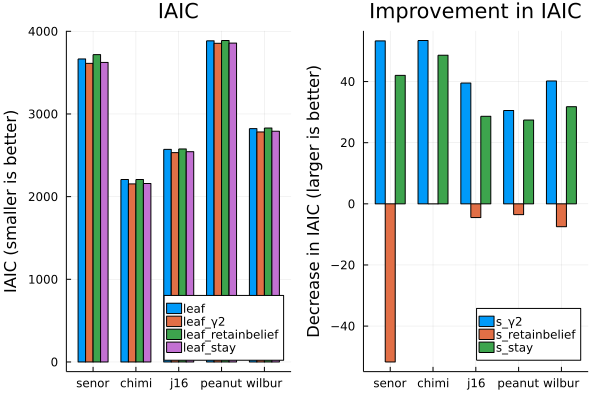

In [5]:
fns = vcat(fns_hmm[[1,2,3,4]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=:bottomright,
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2)

Results:
- Both `γ2` and `stay` lead to a measurable decrease in IAIC across all animals
- `retainbelief` leads to worse model fits

Out of curiosity, what are the values being fit for `retainbelief`?

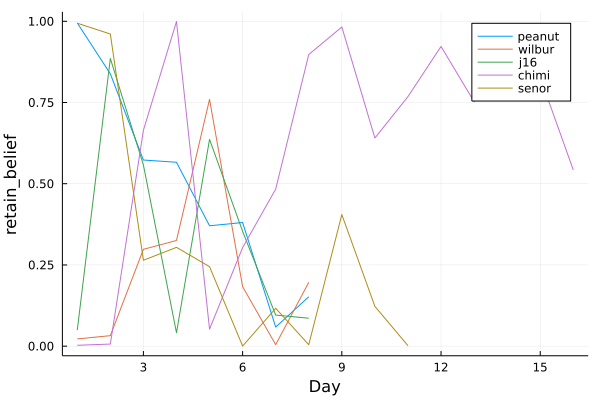

In [6]:
fns = vcat(fns_hmm[[3]])
(results, aics) = load_hmm_results(animals, fns)
peanut_retain = results["peanut", "hmm_leaf_retainbelief"].x[:,5]
peanut_retain = 0.5.+0.5.*erf.(peanut_retain ./ sqrt(2))
chimi_retain = results["chimi", "hmm_leaf_retainbelief"].x[:,5]
chimi_retain = 0.5.+0.5.*erf.(chimi_retain ./ sqrt(2))
j16_retain = results["j16", "hmm_leaf_retainbelief"].x[:,5]
j16_retain = 0.5.+0.5.*erf.(j16_retain ./ sqrt(2))
senor_retain = results["senor", "hmm_leaf_retainbelief"].x[:,5]
senor_retain = 0.5.+0.5.*erf.(senor_retain ./ sqrt(2))
wilbur_retain = results["wilbur", "hmm_leaf_retainbelief"].x[:,5]
wilbur_retain = 0.5.+0.5.*erf.(wilbur_retain ./ sqrt(2))
p = plot()
plot!(peanut_retain, label="peanut")
plot!(wilbur_retain, label="wilbur")
plot!(j16_retain, label="j16")
plot!(chimi_retain, label="chimi")
plot!(senor_retain, label="senor")
xlabel!("Day")
ylabel!("retain_belief")

So intriguingly, we *do* see a steady decrease, with high values at the start for a number of animals

Finally, let's take a look at the effect of including both `γ2` **and** `stay`

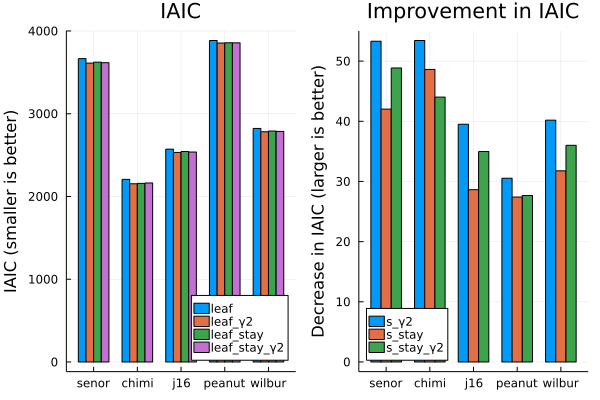

In [7]:
fns = vcat(fns_hmm[[1,2,4]], fns_hmm_stay[1])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=:bottomleft,
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2)

It looks like we're capturing (inadvertently) some very similar behavior with the stay bias versus the alternate leaf. Not deeply surprising, since both add a weight onto the current leaf, though with $\gamma 2$, this weight is before $\beta_\text{stay}$ (which shouldn't matter), and varies based on belief (which should matter)

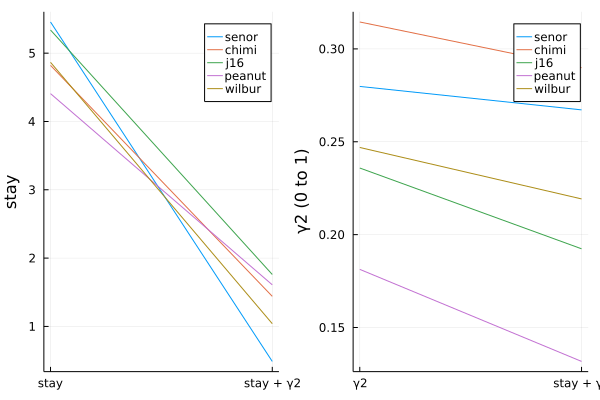

In [8]:
fns = vcat(fns_hmm[[1,2,4]], fns_hmm_stay[1])
(results, aics) = load_hmm_results(animals, fns);

stay_alone = [results[animal, "hmm_leaf_stay"].betas[5] for animal in animals]
stay_together = [results[animal, "hmm_leaf_stay_γ2"].betas[5] for animal in animals]
γ2_alone = [results[animal, "hmm_leaf_γ2"].betas[5] for animal in animals]
γ2_together = [results[animal, "hmm_leaf_stay_γ2"].betas[6] for animal in animals]
γ2_alone = 0.5.+0.5.*erf.(γ2_alone ./ sqrt(2))
γ2_together = 0.5.+0.5.*erf.(γ2_together ./ sqrt(2))

p1 = plot(hcat(stay_alone, stay_together)', labels=permutedims(animals))
xticks!(1:2, ["stay", "stay + γ2"])
ylabel!("stay")
p2 = plot(hcat(γ2_alone, γ2_together)', labels=permutedims(animals))
xticks!(1:2, ["γ2", "stay + γ2"])
ylabel!("γ2 (0 to 1)")
plot(p1, p2)

We can additionally see here that there's a pretty strong tradeoff in $\text{stay}$ vs. $\text{stay} + \gamma 2$, where the $\text{stay}$ bias fit mostly disappears once we can add in $\gamma 2$

# Turn Biases

Here, comparisons are to the fully baseline model.

We're 

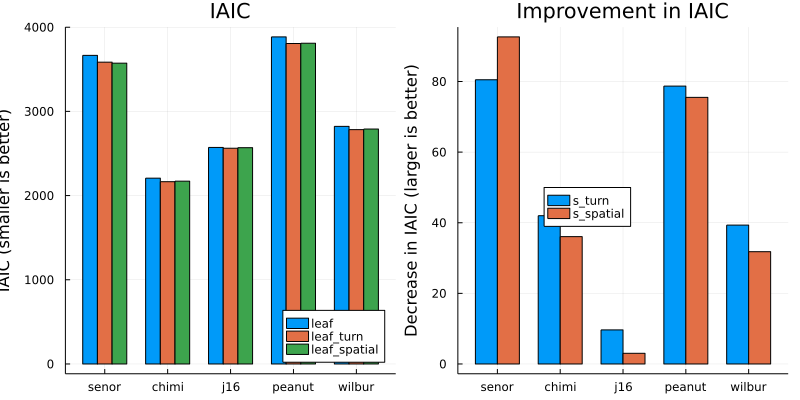

In [9]:
fns = vcat(fns_hmm[[1,5,6]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.35, 0.5),
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2, size=(800, 400))

# Stem Turn Biases

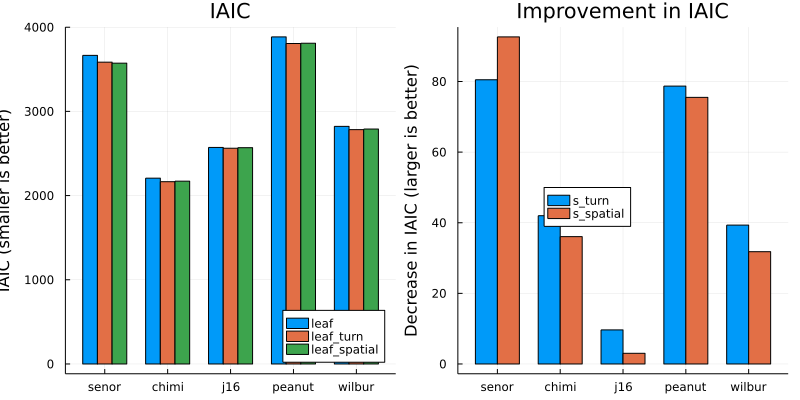

In [10]:
fns = vcat(fns_hmm[[1,5,6]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.35, 0.5),
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2, size=(800, 400))

Below, we're comparing to the `stay` model as baseline, and adding either 1-param or 3-param stem biases

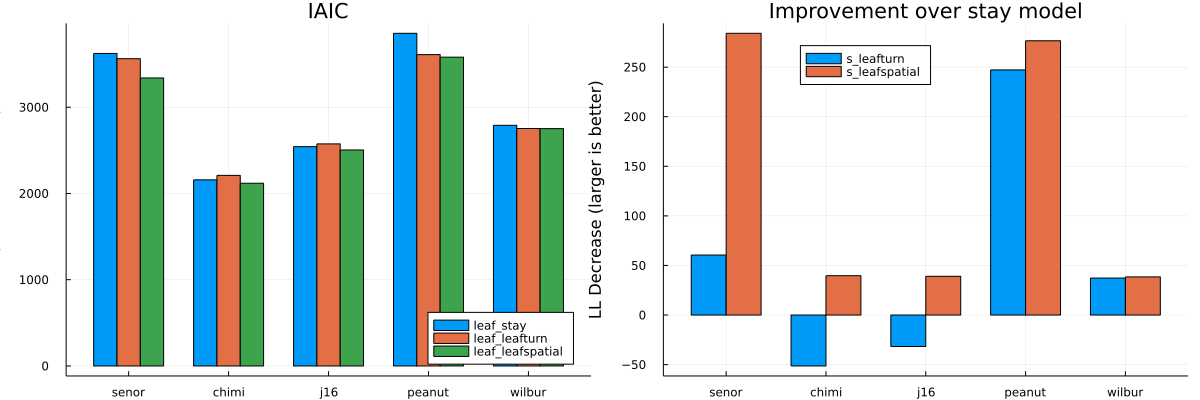

In [11]:
fns = vcat(fns_hmm[[4,7,8]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

Addition of either bias leads to a model fit improvement - however, with 4/5 animals, the 1-parameter version leads to better fit

# Stem + Leaf Biases

Let's now compare the full set of 1/3 parameter biases for both stem and leaf choice

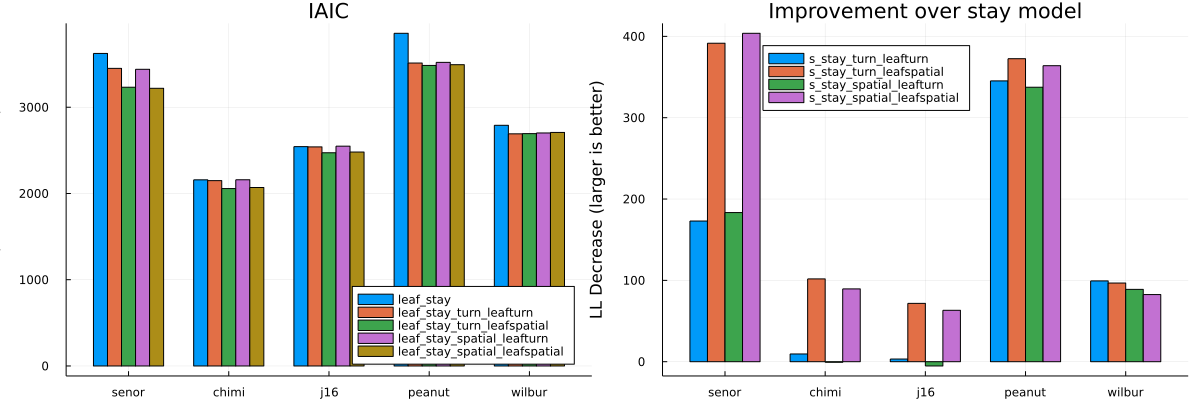

In [12]:
fns = vcat(fns_hmm[4], fns_hmm_stay[5:8])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.28,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

Adding a single-parameter leaf turn bias has mixed effects, in some cases leading to worse model fit

Adding the three-parameter leaf bias, however, provides a huge improvement for all animals except wilbur, where we see marginal difference

# Comparison with γ2

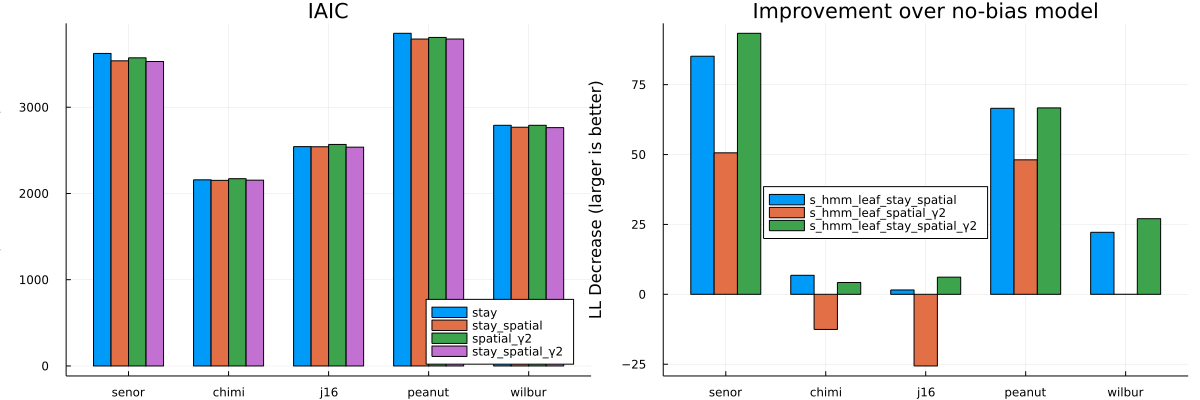

In [13]:
fns = vcat(fns_hmm[4],fns_hmm_stay[4],fns_hmm_γ2[2], fns_hmm_stay_γ2[2])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][10:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][1:end] for x in fns[2:end]]),
    legend=(0.28,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model",
)
plot(p1, p2, size=(1200, 400))

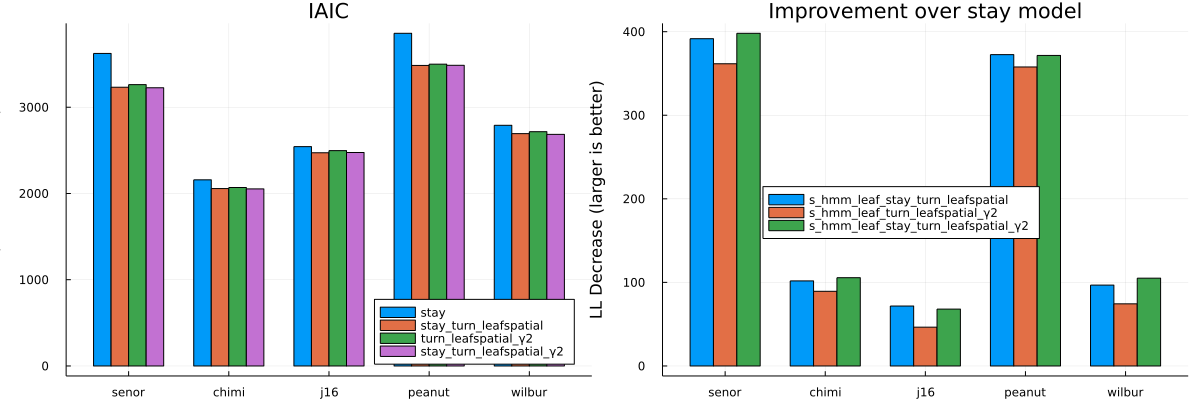

In [14]:
fns = vcat(fns_hmm[4],fns_hmm_stay[6],fns_hmm_γ2[4],fns_hmm_stay_γ2[4])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][10:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][1:end] for x in fns[2:end]]),
    legend=(0.28,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

AICS:
[3231.9785492218202; 2056.6955461069856; 2471.7117505953597; 3484.9896699985256; 2693.9245124502713;;]


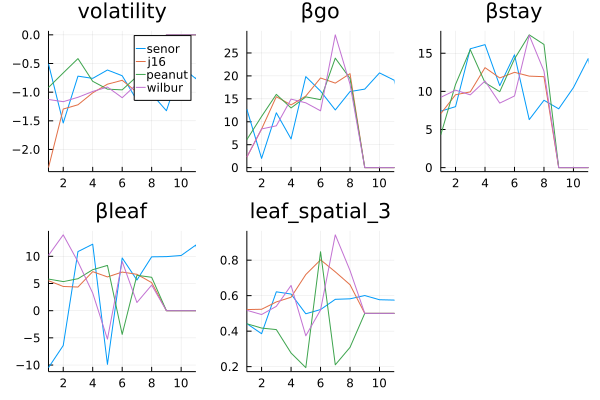

In [15]:
fns = [fns_hmm_stay[6]]
(results, aics) = load_hmm_results(animals, fns)
x = zeros(5,16,9)
x[1,1:11,:] = results[(animals[1], "hmm_leaf_stay_turn_leafspatial")].x
x[2,1:16,:] = results[(animals[2], "hmm_leaf_stay_turn_leafspatial")].x
x[3,1:8,:] = results[(animals[3], "hmm_leaf_stay_turn_leafspatial")].x
x[4,1:8,:] = results[(animals[4], "hmm_leaf_stay_turn_leafspatial")].x
x[5,1:8,:] = results[(animals[5], "hmm_leaf_stay_turn_leafspatial")].x
# [results[(animal, "hmm_leaf_stay_turn_leafspatial")].x for animal in animals]
varnames = results[(animals[1], "hmm_leaf_stay_turn_leafspatial")].varnames

p1 = plot(x[[1,3,4,5], :, 1]',
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[1],
)
xlims!(1,11)

p2 = plot(x[[1,3,4,5], :, 2]',
    labels=nothing,
    title=varnames[2],
)
xlims!(1,11)

p3 = plot(x[[1,3,4,5], :, 3]',
    labels=nothing,
    title=varnames[3],
)
xlims!(1,11)

p4 = plot(x[[1,3,4,5], :, 4]',
    labels=nothing,
    title=varnames[4],
)
xlims!(1,11)

p5 = plot(0.5.+0.5.*erf.(x[[1,3,4,5], :, 9]' ./ sqrt(2)),
    labels=nothing,
    title=varnames[9],
)
xlims!(1,11)
println("AICS:")
println(aics)
plot(p1, p2, p3, p4, p5)

# Leaf Biases

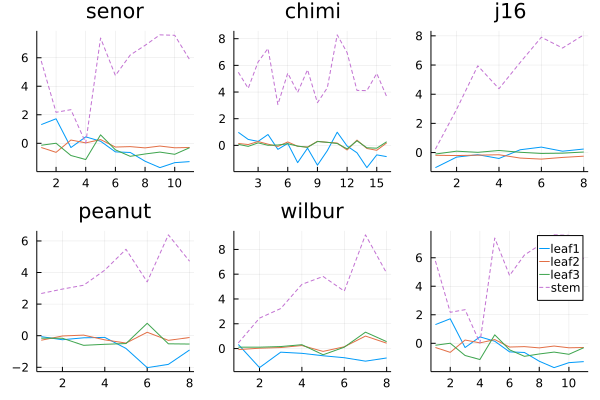

In [17]:
fns = [fns_hmm_stay[6]]
(results, aics) = load_hmm_results(animals, fns)
animal = animals[1]
p1 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[2]
p2 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[3]
p3 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[4]
p4 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[5]
p5 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[1]
p6 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"])
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")

plot(p1, p2, p3, p4, p5, p6)